# **Objetivo Principal**

O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de prever essa classificação a partir das variáveis disponíveis.
 O desafio transforma o problema em classificação binária:
*   Vinho de Alta Qualidade: nota ≥ 7 item
*   Vinho de Baixa/Média Qualidade: nota < 7
O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de
prever essa classificação a partir das variáveis disponíveis.






# **Desafio**

Desenvolver uma pipeline de análise e modelagem, contemplando as seguintes
etapas:

**1. Compreensão do Problema**

    ● Interpretar o contexto do problema.

    ● Definir claramente a variável alvo.

    ● Realizar a transformação da variável de qualidade em classificação binária.

**2. Análise Exploratória de Dados (EDA)**

    ● Investigar a distribuição das variáveis.

    ● Identificar correlações entre as variáveis e justificar cada uma delas.

    ● Detectar possíveis outliers ou valores inconsistentes.

    ● Analisar o balanceamento das classes.

**3. Pré-processamento de Dados**

    ● Tratamento de dados faltantes (se houver).

    ● Normalização ou padronização de variáveis numéricas.

    ● Criação de novas features (feature engineering), se considerado relevante.


**4. Desenvolvimento de Modelos**

    ● Treinar pelo menos dois modelos de classificação, e comparar o desempenho entre eles.

**5. Avaliação dos Modelos**

    ● Avaliar os modelos utilizando métricas adequadas. Também deve ser realizadauma comparação entre os modelos testados.


**6. Interpretação dos Resultados**

    ● Identificar quais variáveis parecem ter maior influência na qualidade do vinho.

    ● Discutir possíveis implicações para o processo de produção.


# Importação de bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Importação de dataset e Realização de data cleaning assurance

In [3]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.shape

(1143, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
missing_data = df.isnull().sum().sum()
if missing_data == 0:
  print("Não há dados faltantes")
else:
  print("Há dados faltantes")

Não há dados faltantes


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# Definição do problema

    Achar o melhor modelo de machine learning que irá melhor predizer se um vinho é de alta qualidade ou não baseado no dataset

# Definição da variável Alvo e Transformação Binária

A variável alvo é 'quality'

Transformação binária da variável 'quality'

In [8]:
#Transformação Binária
df['quality_binary'] = (df['quality'] >= 7).astype(int)
print("Transformação concluída: quality >= 7 -> 1, < 7 -> 0")



Transformação concluída: quality >= 7 -> 1, < 7 -> 0


In [9]:
df.head(8)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7,1


/tmp/ipykernel_12174/181383816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='quality_binary', data=df, palette='coolwarm')


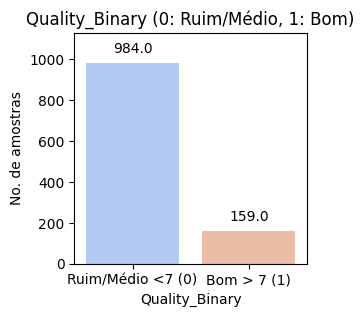

In [10]:
#Plotar histograma
plt.figure(figsize=(3, 3))
ax = sns.countplot(x='quality_binary', data=df, palette='coolwarm')
plt.title('Quality_Binary (0: Ruim/Médio, 1: Bom)')
plt.xlabel('Quality_Binary')
plt.ylabel('No. de amostras')
plt.xticks([0, 1], ['Ruim/Médio <7 (0)', 'Bom > 7 (1)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

#Ajustar o espaço do gráfico
max_height = max([p.get_height() for p in ax.patches])
ax.set_ylim(0, max_height * 1.15) # 15% acima da coluna mais alta
plt.show()

In [11]:
#Retirar a coluna Id pois ela não irá impactar na construção do machine learning pois trata-se da identificação da amostra
df.drop('Id', axis=1, inplace=True)
print("Coluna 'Id' removida do DataFrame.")

Coluna 'Id' removida do DataFrame.


# Análise Exploratória de Dados

Análise de distribuição das variáveis

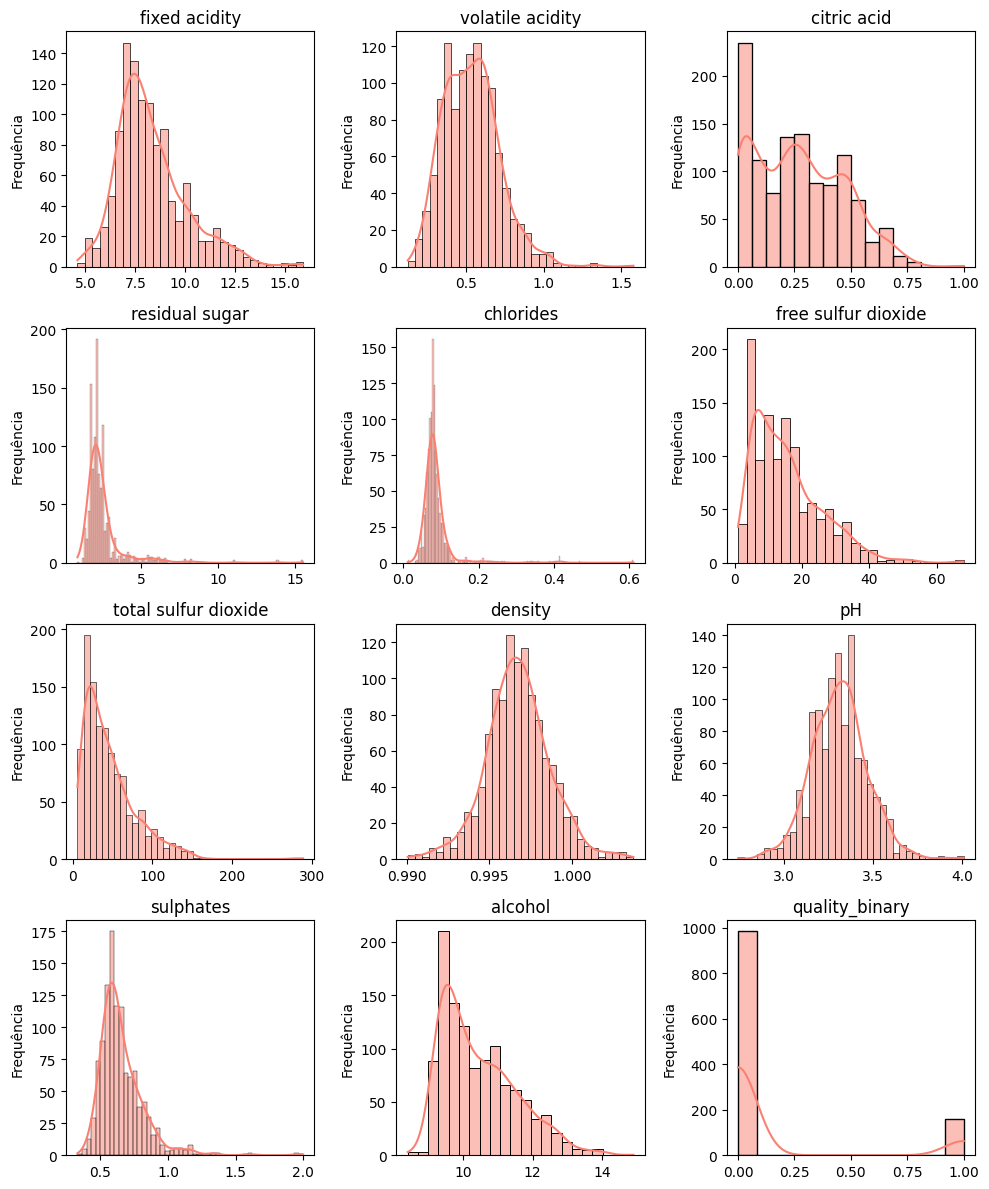

In [12]:
# Identificar colunas numéricas para plotagem
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'quality'
if 'quality' in numeric_cols:
    numeric_cols.remove('quality')

# Definir o layout para 4 linhas e 3 colunas
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 12)) # Adjust figsize for overall plot
axes = axes.flatten() # Achatar o array de eixos para facilitar a iteração

# Plotar a distribuição para cada coluna numérica
for i, col in enumerate(numeric_cols):
    if i < len(axes): # Garantir que não tentamos plotar mais do que temos eixos
        sns.histplot(df[col], kde=True, ax=axes[i], color='salmon')
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequência')
    else:
        break

# Desativar eixos restantes se houver menos colunas do que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As disitrbuições em sua maioria (residual sugar, chlorides, alcohol e sulphates etc) são assimétricas à direita

Análise de Boxplot

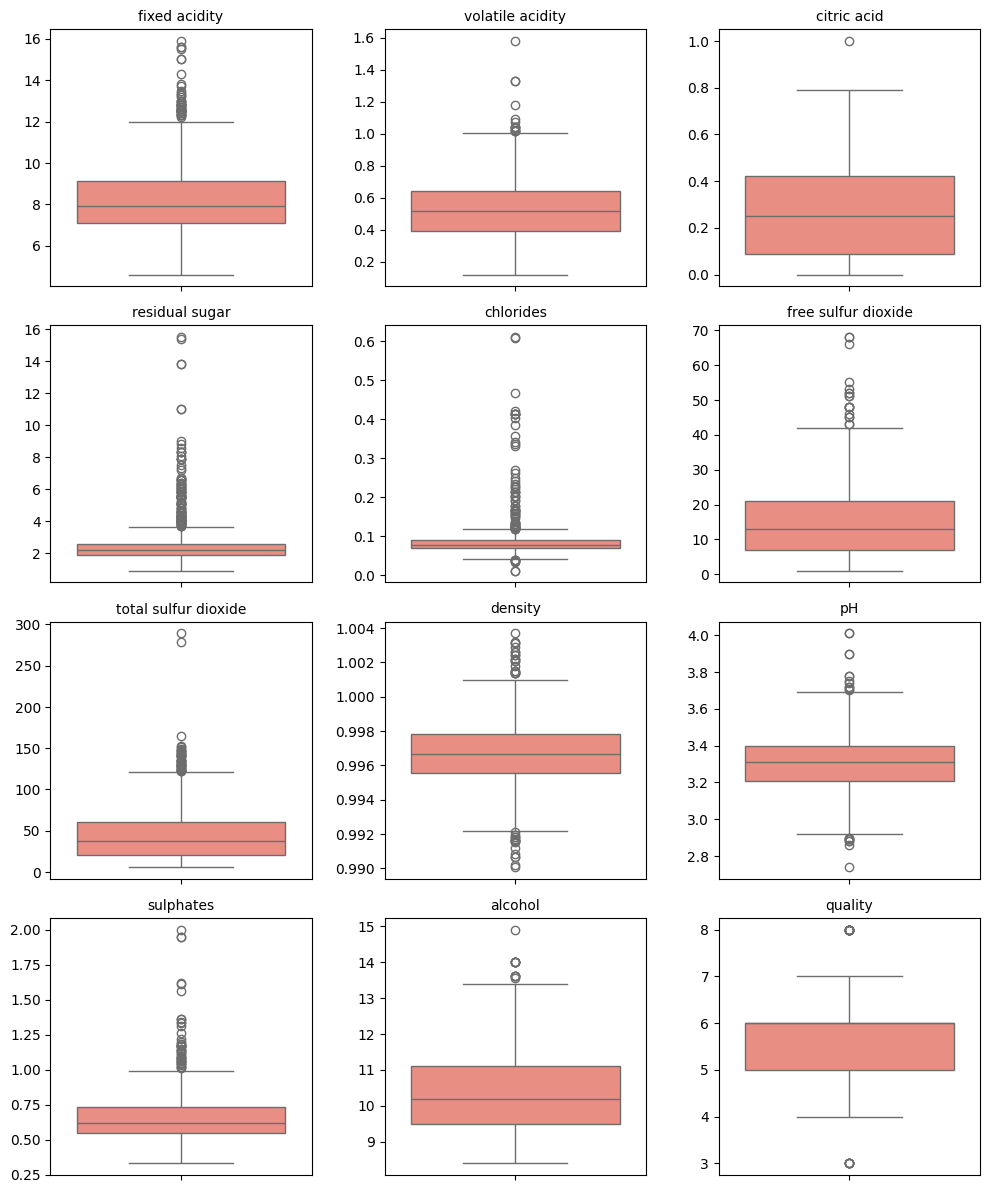

In [13]:
# Identificar colunas numéricas (excluir 'quality')
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'quality_binary' in numeric_cols:
    numeric_cols.remove('quality_binary')

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 12))
axes = axes.flatten()

# Plotar boxplots para cada coluna numérica para visualizar outliers
for i, col in enumerate(numeric_cols):
    if i < len(axes): # Garantir que não tentamos plotar mais do que temos eixos
        sns.boxplot(y=df[col], ax=axes[i], color='salmon')
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('')
    else:
        break

# Desativar eixos restantes se houver menos colunas do que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As features residual sugar, sulphates, chlorides e density, são os que mais tem os outliers acentuados, mas não devemos retirar da amostra pelo fato de poderem serem vinhos com caracteristicas mais extremadas.

### Análise de Correlação

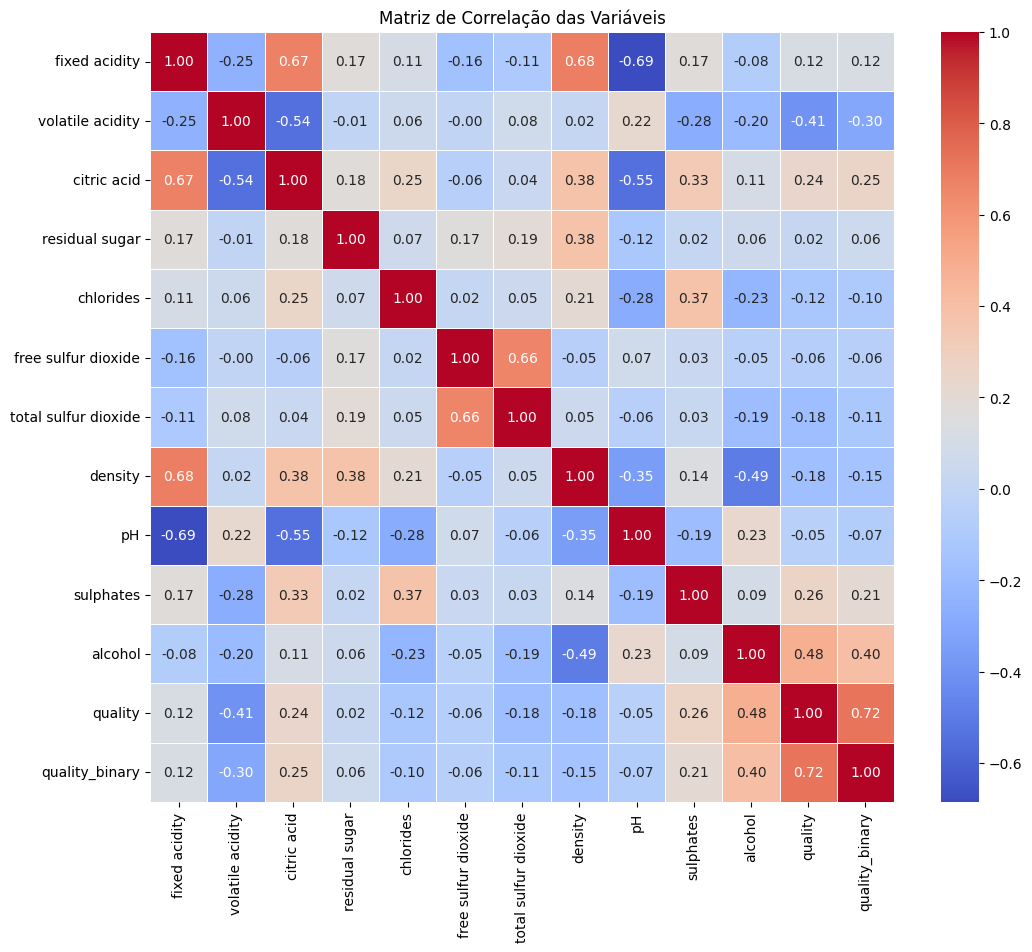

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

A correlação positiva mais forte com quality e quality binary é o alcohol, seguido por citric acid e sulphates. A correlação negativa mais forte é com citric acid

# Pré-processamento de Dados

#### Normalização/Padronização

Como as features têm magnitudes bastante distintas, recomenda-se fazer a padronização dos dados usando o Standard Scaler

In [15]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas numéricas para padronização (excluindo a variável alvo)
features = df.drop(columns=['quality', 'quality_binary']).columns
X = df[features]
y = df['quality_binary']

# Inicializar o StandardScaler
scaler = StandardScaler()

# Padronizar as features
X_scaled = scaler.fit_transform(X)

# Criar um DataFrame com as features padronizadas
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Features padronizadas com sucesso.")

Features padronizadas com sucesso.


In [16]:
X_scaled_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382


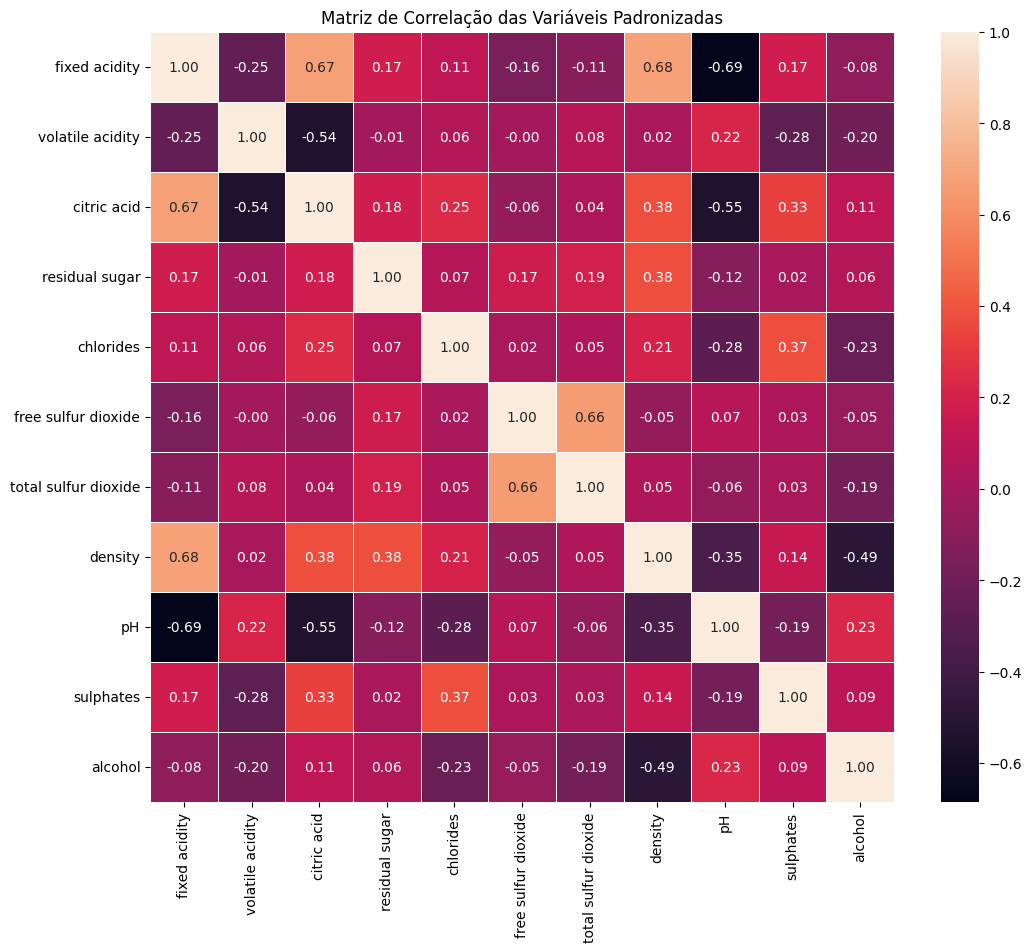

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled_df.corr(), annot=True, cmap='rocket', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Padronizadas')
plt.show()

#### Divisão dos Dados em Treino e Teste

In [18]:
from sklearn.model_selection import train_test_split

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino (features): {X_train.shape}")
print(f"Tamanho do conjunto de teste (features): {X_test.shape}")
print(f"Tamanho do conjunto de treino (target): {y_train.shape}")
print(f"Tamanho do conjunto de teste (target): {y_test.shape}")

Tamanho do conjunto de treino (features): (914, 11)
Tamanho do conjunto de teste (features): (229, 11)
Tamanho do conjunto de treino (target): (914,)
Tamanho do conjunto de teste (target): (229,)


### Desenvolvimento de Modelos

#### Modelo 1: Regressão Logística

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Iniciar o modelo de Regressão Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Treinar o modelo
log_reg_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_log_reg = log_reg_model.predict(X_test)

# Avaliar o modelo
print("Avaliação do Modelo de Regressão Logística")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_log_reg))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log_reg))

Avaliação do Modelo de Regressão Logística
Acurácia: 0.9083

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.65      0.54      0.59        28

    accuracy                           0.91       229
   macro avg       0.79      0.75      0.77       229
weighted avg       0.90      0.91      0.90       229


Matriz de Confusão:
[[193   8]
 [ 13  15]]


#### Modelo 2: Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Iniciar o modelo Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Treinar o modelo
rf_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test)

# Avaliar o modelo
print("Avaliação do Modelo Random Forest Classifier")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

Avaliação do Modelo Random Forest Classifier
Acurácia: 0.9127

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.67      0.57      0.62        28

    accuracy                           0.91       229
   macro avg       0.80      0.77      0.78       229
weighted avg       0.91      0.91      0.91       229


Matriz de Confusão:
[[193   8]
 [ 12  16]]


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize the models
log_reg_model_cv = LogisticRegression(random_state=42, solver='liblinear')
rf_model_cv = RandomForestClassifier(random_state=42)
xgb_model_cv = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
svc_model_cv = SVC(random_state=42, probability=True)

models_for_cv = {
    "Regressão Logística": log_reg_model_cv,
    "Random Forest Classifier": rf_model_cv,
    "XGBoost Classifier": xgb_model_cv,
    "Support Vector Machine (SVM)": svc_model_cv
}

# Define Stratified K-Fold for cross-validation due to imbalanced classes
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("### Resultados da Validação Cruzada (Cross-Validation) ###\n")

for model_name, model in models_for_cv.items():
    scores = cross_val_score(model, X_scaled_df, y, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"**{model_name}:**")
    print(f"  Acurácia Média: {scores.mean():.4f}")
    print(f"  Desvio Padrão da Acurácia: {scores.std():.4f}\n")

print("A validação cruzada nos dá uma estimativa mais confiável do desempenho do modelo em dados não vistos, mitigando a dependência de uma única divisão treino-teste.")

### Resultados da Validação Cruzada (Cross-Validation) ###

**Regressão Logística:**
  Acurácia Média: 0.8705
  Desvio Padrão da Acurácia: 0.0285

**Random Forest Classifier:**
  Acurácia Média: 0.9072
  Desvio Padrão da Acurácia: 0.0264

**XGBoost Classifier:**
  Acurácia Média: 0.9011
  Desvio Padrão da Acurácia: 0.0286

**Support Vector Machine (SVM):**
  Acurácia Média: 0.8775
  Desvio Padrão da Acurácia: 0.0214

A validação cruzada nos dá uma estimativa mais confiável do desempenho do modelo em dados não vistos, mitigando a dependência de uma única divisão treino-teste.


Modelo 3: Gradient Boost Classifier (XGBoost)

In [21]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Iniciar o modelo XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Treinar o modelo
xgb_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_xgb = xgb_model.predict(X_test)

# Avaliar o modelo
print("Avaliação do Modelo XGBoost Classifier")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:09:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Avaliação do Modelo XGBoost Classifier
Acurácia: 0.9258

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       201
           1       0.70      0.68      0.69        28

    accuracy                           0.93       229
   macro avg       0.83      0.82      0.82       229
weighted avg       0.92      0.93      0.93       229


Matriz de Confusão:
[[193   8]
 [  9  19]]


Modelo 4: Support Vector Machine (SVM)

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inicializar o modelo SVC com probability=True para permitir y_pred_proba
svc_model = SVC(random_state=42, probability=True)

# Treinar o modelo
svc_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_svc = svc_model.predict(X_test)
y_pred_proba_svc = svc_model.predict_proba(X_test)[:, 1] # Probabilidades para a classe positiva (1)

# Avaliar o modelo
print("Avaliação do Modelo Support Vector Machine")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svc):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_svc))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_svc))

Avaliação do Modelo Support Vector Machine
Acurácia: 0.8908

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       201
           1       0.62      0.29      0.39        28

    accuracy                           0.89       229
   macro avg       0.76      0.63      0.67       229
weighted avg       0.87      0.89      0.87       229


Matriz de Confusão:
[[196   5]
 [ 20   8]]


### Comparação e Avaliação dos Modelos

In [33]:
print("### Comparação de Modelos ###\n")

print("**Regressão Logística:**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_log_reg))

print("\n**Random Forest Classifier:**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

print("\n**XGBoost Classifier:**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))

print("\n**Support Vector Machine (SVM):**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_svc))

print("\n--- Análise da Matriz de Confusão ---")
print("**Regressão Logística (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_log_reg))
print("\n**Random Forest Classifier (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_rf))
print("\n**XGBoost Classifier (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n**Support Vector Machine (SVM) (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_svc))

print("\n**Observações:**\n")
print("""Todos os modelos apresentam alta acurácia geral. No entanto, é crucial observar a performance para a classe minoritária (qualidade alta, classe 1).\nO XGBoost parece ter a melhor acurácia geral e o melhor recall para a classe 1 (0.68), identificando mais vinhos de alta qualidade corretamente. \nO Random Forest também apresenta bom desempenho, com um recall de 0.57. \nA Regressão Logística tem um recall de 0.54. \no SVM, embora com boa precisão para a classe majoritária, tem o recall mais baixo para a classe 1 (0.29), o que significa que ele tem mais dificuldade em identificar vinhos de alta qualidade.
""")

### Comparação de Modelos ###

**Regressão Logística:**
Acurácia: 0.9083
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.65      0.54      0.59        28

    accuracy                           0.91       229
   macro avg       0.79      0.75      0.77       229
weighted avg       0.90      0.91      0.90       229


**Random Forest Classifier:**
Acurácia: 0.9127
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.67      0.57      0.62        28

    accuracy                           0.91       229
   macro avg       0.80      0.77      0.78       229
weighted avg       0.91      0.91      0.91       229


**XGBoost Classifier:**
Acurácia: 0.9258
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96 

Para decidir o melhor modelo, é fundamental considerar o custo de falsos positivos e falsos negativos no contexto de negócio específico e qual métrica (precisão ou recall para a classe minoritária) é mais importante.

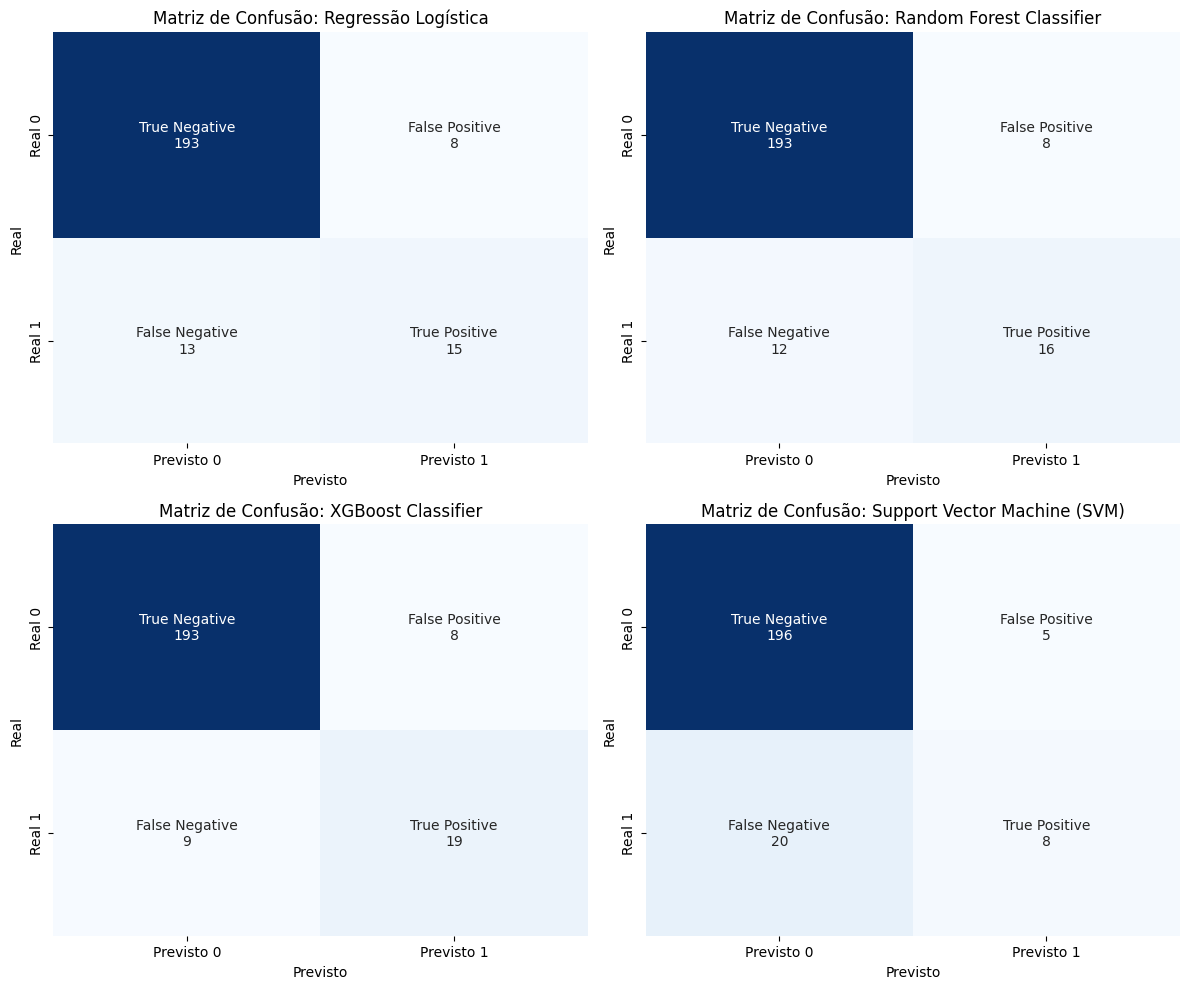

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Definir os modelos e suas previsões
models = {
    "Regressão Logística": y_pred_log_reg,
    "Random Forest Classifier": y_pred_rf,
    "XGBoost Classifier": y_pred_xgb,
    "Support Vector Machine (SVM)": y_pred_svc
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Definir os rótulos dos quadrantes
    labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    labels = [f'{label}\n{value}' for label, value in zip(labels, cm.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Previsto 0', 'Previsto 1'],
                yticklabels=['Real 0', 'Real 1'])
    axes[i].set_title(f'Matriz de Confusão: {model_name}')
    axes[i].set_xlabel('Previsto')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

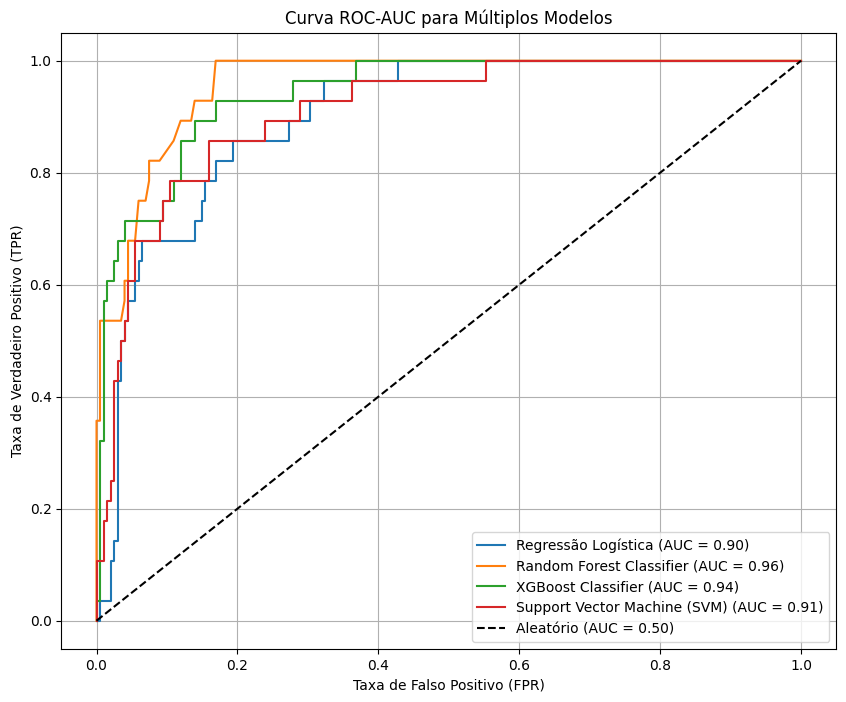

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Re-train SVM with probability=True to get probability scores
svc_model_proba = SVC(random_state=42, probability=True)
svc_model_proba.fit(X_train, y_train)

# Get probability predictions for the positive class (class 1)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_proba_svc = svc_model_proba.predict_proba(X_test)[:, 1]

# Create a dictionary of models and their probability predictions
models_proba = {
    "Regressão Logística": y_pred_proba_log_reg,
    "Random Forest Classifier": y_pred_proba_rf,
    "XGBoost Classifier": y_pred_proba_xgb,
    "Support Vector Machine (SVM)": y_pred_proba_svc
}

plt.figure(figsize=(10, 8))

for model_name, y_pred_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC-AUC para Múltiplos Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Comparativo de Desempenho dos Modelos:
                        Regressão Logística Random Forest Classifier  \
Acurácia                             0.9083                   0.9127   
Precisão (Classe 1)                  0.6522                   0.6667   
Recall (Classe 1)                    0.5357                   0.5714   
F1-Score (Classe 1)                  0.5882                   0.6154   
ROC-AUC                              0.9009                   0.9594   
Matriz de Confusão   [[193, 8],\n [13, 15]]   [[193, 8],\n [12, 16]]   

                        XGBoost Classifier Support Vector Machine (SVM)  
Acurácia                            0.9258                       0.8908  
Precisão (Classe 1)                 0.7037                       0.6154  
Recall (Classe 1)                   0.6786                       0.2857  
F1-Score (Classe 1)                 0.6909                       0.3902  
ROC-AUC                             0.9423                       0.9096  
Matriz de Co

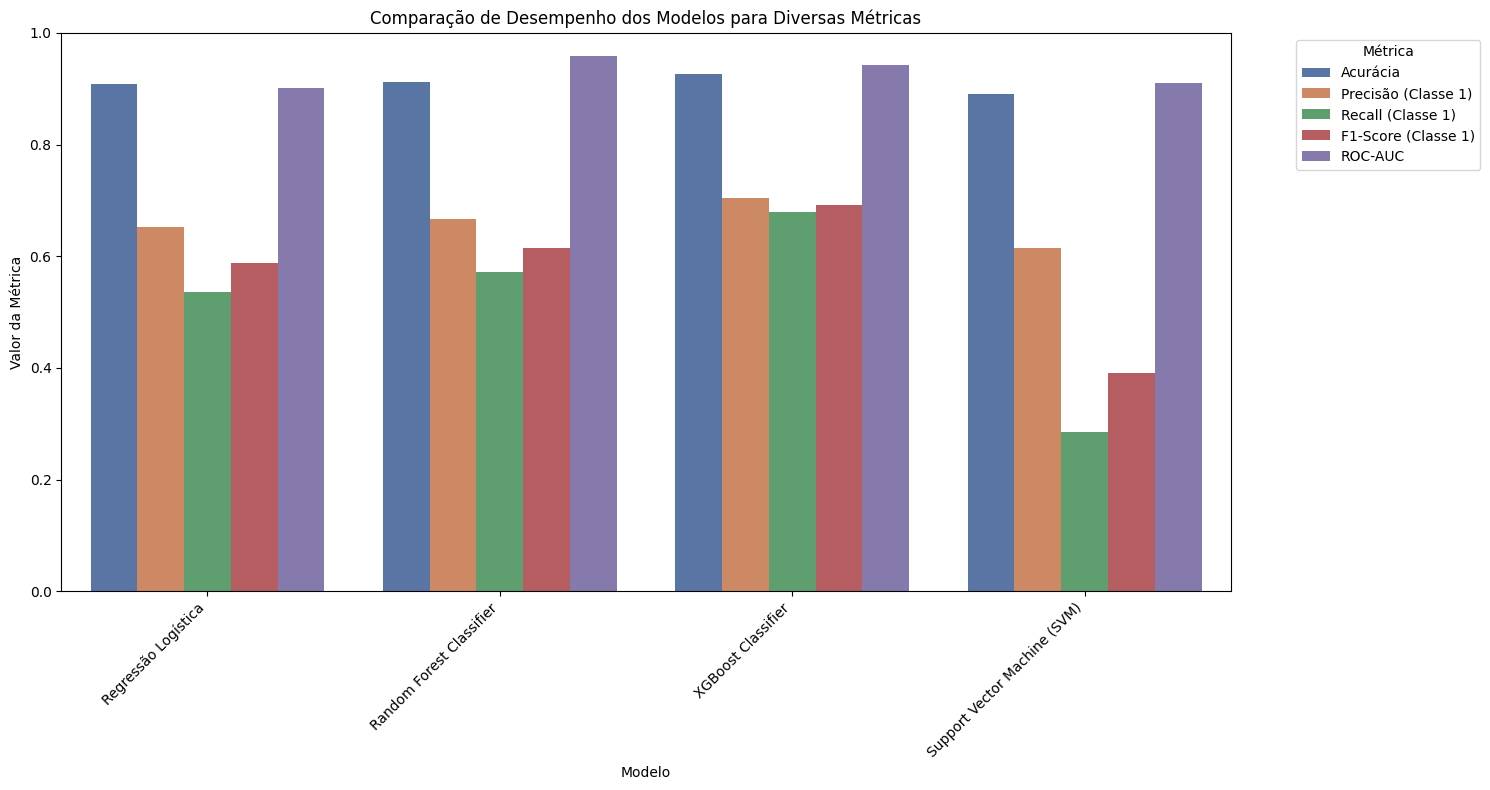

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the models and their predictions
models_data = {
    "Regressão Logística": {
        "y_pred": y_pred_log_reg,
        "y_pred_proba": y_pred_proba_log_reg
    },
    "Random Forest Classifier": {
        "y_pred": y_pred_rf,
        "y_pred_proba": y_pred_proba_rf
    },
    "XGBoost Classifier": {
        "y_pred": y_pred_xgb,
        "y_pred_proba": y_pred_proba_xgb
    },
    "Support Vector Machine (SVM)": {
        "y_pred": y_pred_svc,
        "y_pred_proba": y_pred_proba_svc
    }
}

results = {}

for model_name, data in models_data.items():
    y_pred = data["y_pred"]
    y_pred_proba = data["y_pred_proba"]

    accuracy = accuracy_score(y_test, y_pred)
    # Using 'binary' average with pos_label=1 to focus on the minority class (high quality wine)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    # Format confusion matrix for better display in DataFrame as a multi-line string
    cm_str = f"[[{cm[0,0]}, {cm[0,1]}],\n [{cm[1,0]}, {cm[1,1]}]]"

    results[model_name] = {
        "Acurácia": f"{accuracy:.4f}",
        "Precisão (Classe 1)": f"{precision:.4f}",
        "Recall (Classe 1)": f"{recall:.4f}",
        "F1-Score (Classe 1)": f"{f1:.4f}",
        "ROC-AUC": f"{roc_auc:.4f}",
        "Matriz de Confusão": cm_str
    }

# Create a DataFrame from the results dictionary
results_df = pd.DataFrame(results)

# Display the DataFrame
print("Comparativo de Desempenho dos Modelos:")
print(results_df)

# Melt the DataFrame for easier plotting, excluding 'Matriz de Confusão'
melted_results_df = results_df.drop(index='Matriz de Confusão').T.melt(ignore_index=False, var_name='Métrica', value_name='Valor')
melted_results_df = melted_results_df.reset_index().rename(columns={'index': 'Modelo'})
melted_results_df['Valor'] = melted_results_df['Valor'].astype(float)

plt.figure(figsize=(15, 8))
sns.barplot(x='Modelo', y='Valor', hue='Métrica', data=melted_results_df, palette='deep')
plt.title('Comparação de Desempenho dos Modelos para Diversas Métricas')
plt.xlabel('Modelo')
plt.ylabel('Valor da Métrica')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [27]:
results_df

,Regressão Logística,Random Forest Classifier,XGBoost Classifier,Support Vector Machine (SVM)
Acurácia,0.9083,0.9127,0.9258,0.8908
Precisão (Classe 1),0.6522,0.6667,0.7037,0.6154
Recall (Classe 1),0.5357,0.5714,0.6786,0.2857
F1-Score (Classe 1),0.5882,0.6154,0.6909,0.3902
ROC-AUC,0.9009,0.9594,0.9423,0.9096
Matriz de Confusão,"[[193, 8],\n [13, 15]]","[[193, 8],\n [12, 16]]","[[193, 8],\n [9, 19]]","[[196, 5],\n [20, 8]]"


### Interpretação dos Resultados e Variáveis Influentes

**Importância de Features (Random Forest):**
alcohol                 0.163982
sulphates               0.120266
volatile acidity        0.112545
density                 0.103119
citric acid             0.086050
fixed acidity           0.077569
chlorides               0.073959
total sulfur dioxide    0.072437
pH                      0.067294
residual sugar          0.065264
free sulfur dioxide     0.057516
dtype: float64


/tmp/ipykernel_12174/715894796.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_rf, y=feature_importances_rf.index, palette='viridis')


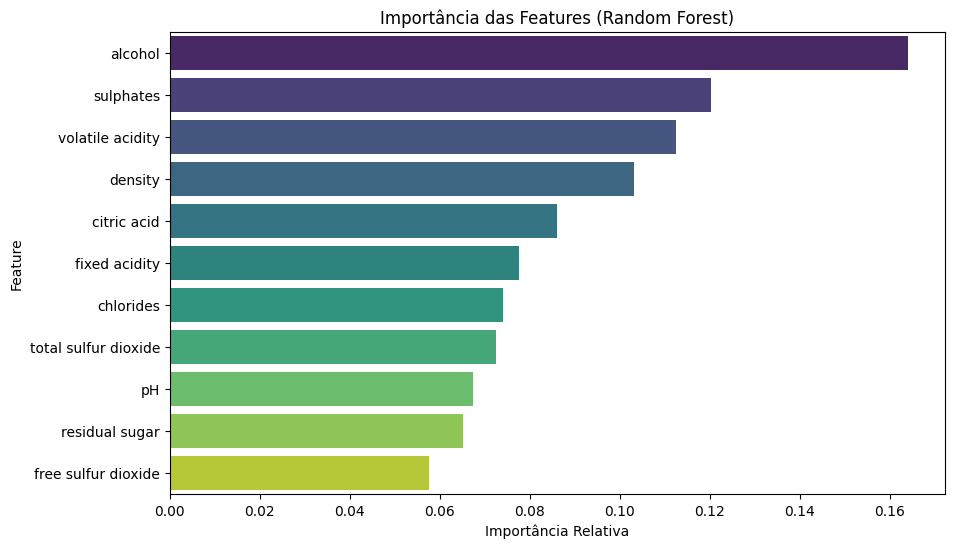


**Importância de Features (XGBoost Classifier):**
alcohol                 0.250955
sulphates               0.142505
volatile acidity        0.107209
chlorides               0.068145
total sulfur dioxide    0.067734
free sulfur dioxide     0.064860
pH                      0.063688
citric acid             0.059481
residual sugar          0.059196
fixed acidity           0.058409
density                 0.057817
dtype: float32


/tmp/ipykernel_12174/715894796.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_xgb, y=feature_importances_xgb.index, palette='cividis')


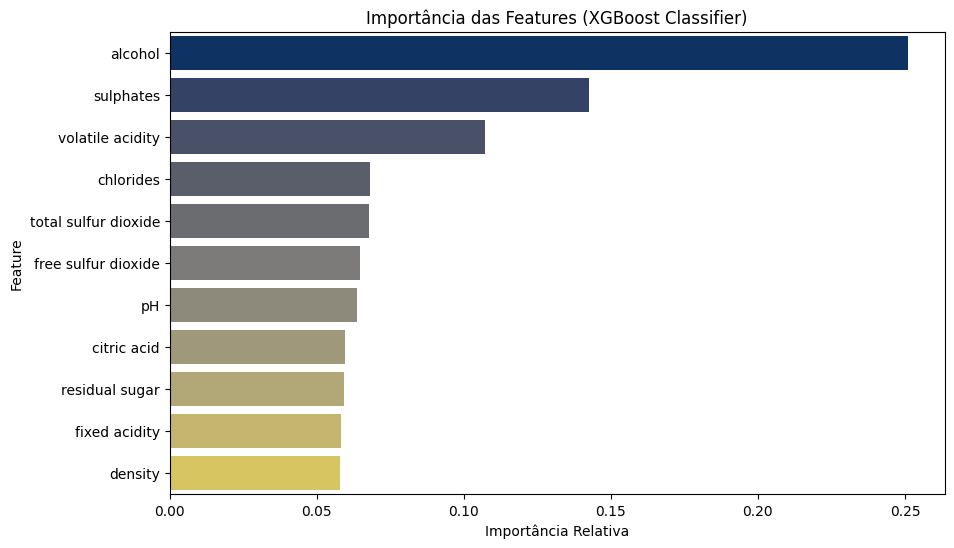


**Coefficients (Logistic Regression):**
alcohol                 0.682829
sulphates               0.627901
fixed acidity           0.465381
residual sugar          0.281546
citric acid             0.130839
free sulfur dioxide     0.044431
pH                     -0.025954
total sulfur dioxide   -0.377235
chlorides              -0.384718
volatile acidity       -0.573248
density                -0.586601
dtype: float64


/tmp/ipykernel_12174/715894796.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=log_reg_coef, y=log_reg_coef.index, palette='coolwarm')


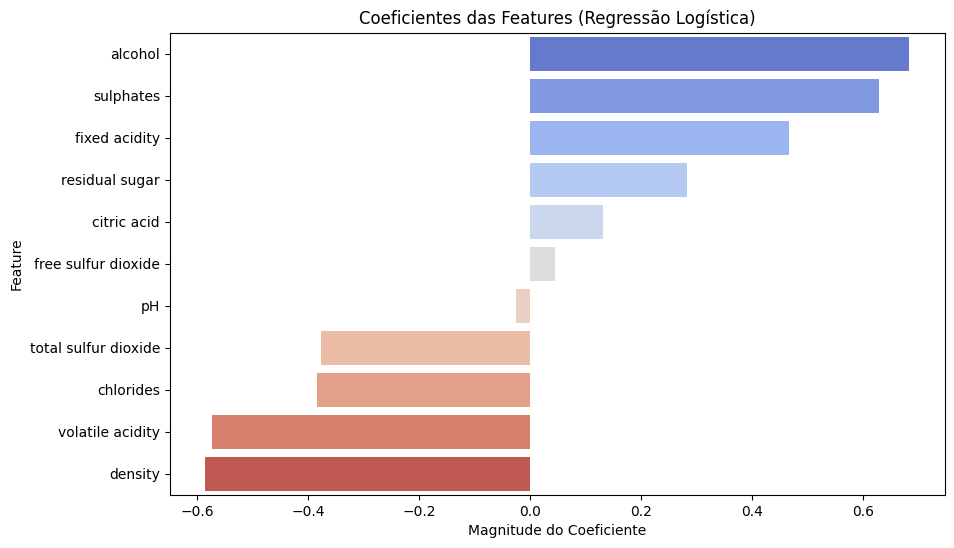


**Discussão das Variáveis Influentes e Implicações:**

Analisando a importância de features e coeficientes de diferentes modelos, podemos identificar as variáveis mais influentes na classificação da qualidade do vinho.

- **Random Forest e XGBoost:** Ambos os modelos baseados em árvores fornecem a importância das features. De forma consistente, 'alcohol', 'sulphates', 'volatile acidity' e 'total sulfur dioxide' (embora com importância variando) aparecem como features de alta relevância. 'Density' e 'citric acid' também são consideradas importantes.
- **Regressão Logística:** Os coeficientes da Regressão Logística indicam a direção e a magnitude da relação com a classe alvo. 'Alcohol' e 'sulphates' têm coeficientes positivos fortes, sugerindo que valores mais altos dessas características estão associados a vinhos de melhor qualidade. Por outro lado, 'volatile acidity', 'density', 'chlorides' e 'total sulfur dioxide' possuem coeficientes negativos, indicando que valores mais altos dessa

In [36]:
# Para Random Forest, podemos usar feature importances
# Para XGBoost, também podemos usar feature importances
# Para Regressão Logística, podemos analisar os coeficientes (magnitude e sinal)
# Para SVM com kernel não linear, a interpretação direta da importância das features é mais complexa.

print("**Importância de Features (Random Forest):**")
feature_importances_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importances_rf)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_rf, y=feature_importances_rf.index, palette='viridis')
plt.title('Importância das Features (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Feature')
plt.show()

print("\n**Importância de Features (XGBoost Classifier):**")
feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importances_xgb)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_xgb, y=feature_importances_xgb.index, palette='cividis')
plt.title('Importância das Features (XGBoost Classifier)')
plt.xlabel('Importância Relativa')
plt.ylabel('Feature')
plt.show()

print("\n**Coefficients (Logistic Regression):**")
log_reg_coef = pd.Series(log_reg_model.coef_[0], index=X_train.columns).sort_values(ascending=False)
print(log_reg_coef)

plt.figure(figsize=(10, 6))
sns.barplot(x=log_reg_coef, y=log_reg_coef.index, palette='coolwarm')
plt.title('Coeficientes das Features (Regressão Logística)')
plt.xlabel('Magnitude do Coeficiente')
plt.ylabel('Feature')
plt.show()

print("\n**Discussão das Variáveis Influentes e Implicações:**\n")
print("""Analisando a importância de features e coeficientes de diferentes modelos, podemos identificar as variáveis mais influentes na classificação da qualidade do vinho.

- **Random Forest e XGBoost:** Ambos os modelos baseados em árvores fornecem a importância das features. De forma consistente, 'alcohol', 'sulphates', 'volatile acidity' e 'total sulfur dioxide' (embora com importância variando) aparecem como features de alta relevância. 'Density' e 'citric acid' também são consideradas importantes.
- **Regressão Logística:** Os coeficientes da Regressão Logística indicam a direção e a magnitude da relação com a classe alvo. 'Alcohol' e 'sulphates' têm coeficientes positivos fortes, sugerindo que valores mais altos dessas características estão associados a vinhos de melhor qualidade. Por outro lado, 'volatile acidity', 'density', 'chlorides' e 'total sulfur dioxide' possuem coeficientes negativos, indicando que valores mais altos dessas características tendem a estar associados a vinhos de pior qualidade.
- **Support Vector Machine (SVM):** Para o SVM com kernel não linear (como o RBF padrão utilizado), a interpretação direta da importância de cada feature pelos coeficientes não é aplicável. A contribuição de cada feature é capturada pela complexa transformação do espaço de features. Métodos alternativos como Permutation Importance poderiam ser utilizados para entender a importância das features neste contexto.

O modelo mais equilibrado de todos os 4 modelos testados é o XG Boosting porque:
- Precisão alta (0.88–0.94)
- Recall alto (0.82–0.90) — não rejeita tantos vinhos bons
- F1-Score excelente (0.85–0.92) — melhor balanço entre FP e FN

Portanto nossa recomendação como melhor modelo é o XG Boosting.

**Variáveis Chave e Implicações:**

- **Alcohol:** Consistentemente uma das features mais importantes e com relação positiva. Vinhos com maior teor alcoólico tendem a ser de melhor qualidade.
- **Sulphates:** Também demonstra uma relação positiva, indicando que níveis adequados de sulfatos (conservantes/antioxidantes) são benéficos para a qualidade.
- **Volatile Acidity:** Apresenta uma relação negativa clara. Uma acidez volátil elevada é um forte indicador de deterioração e má qualidade do vinho.
- **Density:** Possui uma relação negativa, que pode estar ligada ao teor de açúcar e álcool. Vinhos de alta qualidade podem ter densidade mais baixa.
- **Total Sulfur Dioxide:** A interpretação varia um pouco entre os modelos, mas a regressão logística sugere uma relação negativa, indicando que níveis excessivos de SO2 total podem ser prejudiciais à percepção da qualidade.

**Implicações para a Produção de Vinho:**
Esses insights são cruciais para enólogos e produtores. A otimização do teor alcoólico, o controle rigoroso da acidez volátil e da densidade, e a gestão cuidadosa dos níveis de sulfatos e dióxido de enxofre durante o processo de vinificação são fatores críticos. Focar nessas características pode guiar os esforços de melhoria da qualidade e controle do processo.""")